In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

base_temp = 10.0
amplitude = 14

rows = []

for year in [2021, 2022, 2023, 2024]:
    for month in range(1, 13):
        seasonal = amplitude * np.cos(
            (month - 7) / 12 * 2 * np.pi
        )

        temperature = (
            base_temp
            + seasonal
            + np.random.normal(0, 1)
        )

        humidity = (
            75
            - 0.6 * temperature
            + np.random.normal(0, 4)
        )

        rows.append({
            "рік": year,
            "місяць": month,
            "температура": temperature,
            "вологість": humidity
        })

climate = pd.DataFrame(rows)

climate.head()

,рік,місяць,температура,вологість
0,2021,1,-3.503286,76.548914
1,2021,2,-1.476667,81.978120
2,2021,3,2.765847,72.403944
3,2021,4,11.579213,71.122211
4,2021,5,16.530526,67.251925


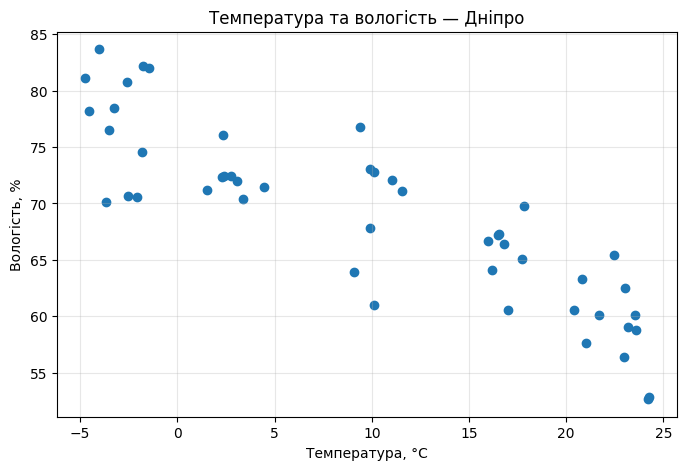

In [2]:
plt.figure(figsize=(8, 5))

plt.scatter(
    climate["температура"],
    climate["вологість"]
)

plt.xlabel("Температура, °C")
plt.ylabel("Вологість, %")
plt.title("Температура та вологість — Дніпро")

plt.grid(alpha=0.3)
plt.show()

На діаграмі розсіювання видно від'ємний зв'язок між
температурою та вологістю.

При збільшенні температури вологість у середньому
зменшується.

Точки не лежать точно на одній прямій через випадковий
шум, проте загальна тенденція добре помітна.

In [3]:
pearson_r, pearson_p = stats.pearsonr(
    climate["температура"],
    climate["вологість"]
)

print("Коефіцієнт Пірсона:", pearson_r)
print("p-value:", pearson_p)

Коефіцієнт Пірсона: -0.8637207895660062
p-value: 2.750668251416261e-15


In [4]:
print(
    climate["температура"].corr(
        climate["вологість"]
    )
)

-0.8637207895660062


Коефіцієнт кореляції Пірсона має від'ємне значення,
близьке за модулем до 1.

Це свідчить про сильний від'ємний лінійний зв'язок:
зі збільшенням температури вологість має тенденцію
до зменшення.

p-value є значно меншим за 0.05, тому нульову гіпотезу
про відсутність лінійної кореляції відхиляємо.

Отже, між температурою та вологістю в згенерованому
наборі даних існує статистично значущий лінійний зв'язок.

Водночас сама наявність кореляції не доводить
причинно-наслідковий зв'язок.

In [5]:
spearman_r, spearman_p = stats.spearmanr(
    climate["температура"],
    climate["вологість"]
)

print("Пірсон:")
print("r =", pearson_r)
print("p-value =", pearson_p)

print("\nСпірмен:")
print("rho =", spearman_r)
print("p-value =", spearman_p)

Пірсон:
r = -0.8637207895660062
p-value = 2.750668251416261e-15

Спірмен:
rho = -0.8596396005210595
p-value = 5.178819284403977e-15


Коефіцієнти Пірсона і Спірмена в цьому наборі даних
мають близькі за змістом результати: обидва показують
сильний від'ємний зв'язок між температурою та вологістю.

Пірсон оцінює силу лінійного зв'язку між двома
числовими змінними.

Спірмен працює з рангами значень і оцінює монотонний
зв'язок. Тому він менш чутливий до викидів та не
вимагає, щоб зв'язок був саме лінійним.

У наших даних залежність приблизно лінійна, тому
результати Пірсона і Спірмена досить близькі.

In [6]:
x = np.arange(1, 21)

y = x ** 2

pearson_nonlinear, _ = stats.pearsonr(x, y)
spearman_nonlinear, _ = stats.spearmanr(x, y)

print("Пірсон:", pearson_nonlinear)
print("Спірмен:", spearman_nonlinear)

Пірсон: 0.9713482021963805
Спірмен: 1.0


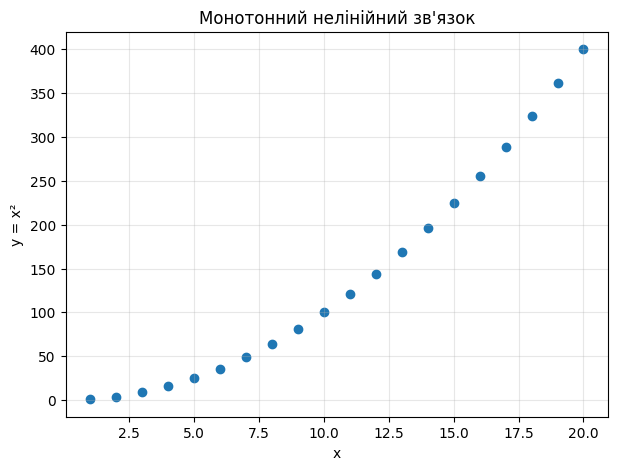

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y = x²")
plt.title("Монотонний нелінійний зв'язок")

plt.grid(alpha=0.3)
plt.show()

У прикладі y = x² для додатних x залежність є
монотонною, але нелінійною.

Коефіцієнт Спірмена дорівнює 1, оскільки зі збільшенням
x значення y завжди збільшується і порядок рангів
повністю зберігається.

Коефіцієнт Пірсона менший за 1, оскільки залежність
не є прямою лінією.

Таким чином, Спірмен може краще відображати сильний
монотонний нелінійний зв'язок.

In [8]:
climate["номер_спостереження"] = np.arange(1, len(climate) + 1)

climate["відхилення_температури"] = (
    climate["температура"] - base_temp
)

numeric_data = climate[
    [
        "місяць",
        "температура",
        "вологість",
        "номер_спостереження",
        "відхилення_температури"
    ]
]

corr_matrix = numeric_data.corr()

corr_matrix

,місяць,температура,вологість,номер_спостереження,відхилення_температури
місяць,1.000000,0.203237,-0.214995,0.249185,0.203237
температура,0.203237,1.000000,-0.863721,0.048780,1.000000
вологість,-0.214995,-0.863721,1.000000,0.002712,-0.863721
номер_спостереження,0.249185,0.048780,0.002712,1.000000,0.048780
відхилення_температури,0.203237,1.000000,-0.863721,0.048780,1.000000


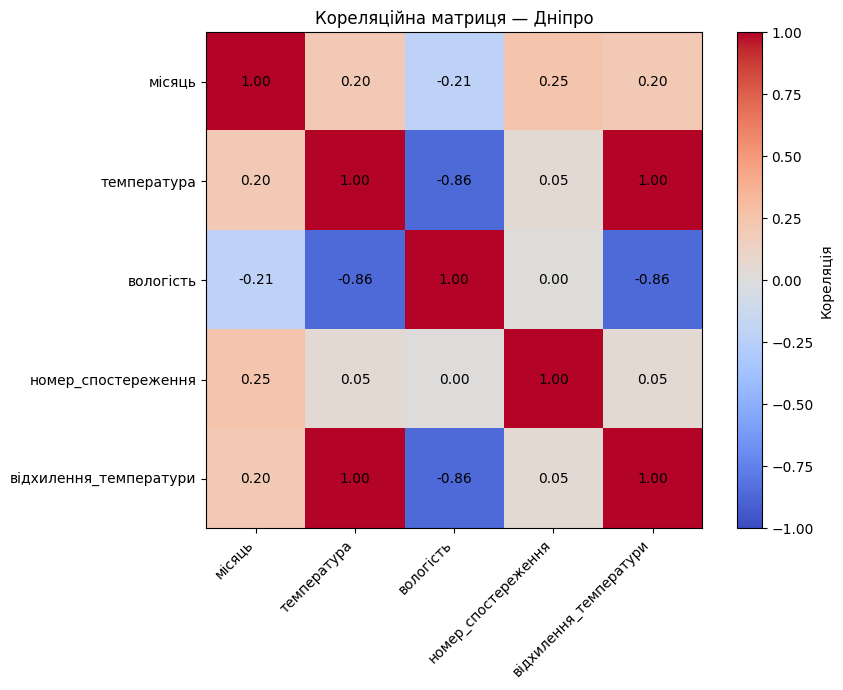

In [9]:
plt.figure(figsize=(9, 7))

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Кореляція")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Кореляційна матриця — Дніпро")
plt.tight_layout()
plt.show()

Кореляційна матриця дозволяє одночасно оцінити
попарні лінійні зв'язки між числовими змінними.

На головній діагоналі всі значення дорівнюють 1,
оскільки кожна змінна ідеально корелює сама із собою.

Температура та відхилення температури мають кореляцію 1,
оскільки друга змінна безпосередньо отримана з першої
відніманням константи.

Між температурою та вологістю спостерігається сильна
від'ємна кореляція.

Важливо пам'ятати, що висока кореляція сама по собі
не означає причинно-наслідкового зв'язку.

1. Чим відрізняються коефіцієнти Пірсона і Спірмена?

Коефіцієнт Пірсона вимірює силу та напрямок лінійного
зв'язку між двома числовими змінними.

Коефіцієнт Спірмена працює з рангами та вимірює силу
монотонного зв'язку. Він не вимагає, щоб залежність
була лінійною, та є менш чутливим до викидів.

Тому Пірсон краще підходить для лінійних залежностей,
а Спірмен — для монотонних залежностей або даних,
для яких припущення Пірсона виконуються погано.


2. Що означає кореляція r = -0.8?

Значення r = -0.8 означає сильний від'ємний лінійний
зв'язок.

У середньому зі збільшенням однієї змінної інша має
тенденцію зменшуватися.

Значення близьке до -1, тому зв'язок є сильним.
Проте це не означає, що одна змінна обов'язково
є причиною зміни іншої.


3. Чому кореляція не означає причинність?

Кореляція показує статистичний зв'язок між змінними,
але сама по собі не встановлює його причину.

Обидві змінні можуть залежати від третього фактора.
Також зв'язок може виникнути випадково або мати
складніший механізм.

Для встановлення причинності потрібні додаткові
дослідження, контроль інших факторів та відповідний
дизайн дослідження.


4. Навіщо перед обчисленням кореляції будувати
діаграму розсіювання?

Діаграма розсіювання дозволяє побачити форму зв'язку
між змінними.

За нею можна визначити, чи є зв'язок приблизно
лінійним, чи присутня нелінійність, окремі групи
спостережень або викиди.

Одне значення коефіцієнта кореляції не показує всіх
цих особливостей, тому візуальна перевірка даних
є важливим етапом кореляційного аналізу.